# Eventos de violencia organizada (UCDP GED)

El dataset UCDP GED documenta eventos de violencia organizada en el mundo, incluyendo detalles temporales, geográficos y del tipo de conflicto. Este proyecto busca explorar patrones de violencia, tendencias temporales, distribución geográfica y posibles indicadores predictivos.

El mismo puede descargarse desde https://ucdp.uu.se/downloads/index.html#ged_global

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Estilo global: minimalista ──────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : False,
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
})


In [33]:
data = pd.read_csv("dataset/GEDEvent_v25_1.csv", low_memory=False)
data.head(5)

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29 00:00:00.000,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN


## Descripción general del dataset

In [34]:
# ─────────────────────────────────────────────
# RESUMEN GENERAL — UCDP GED
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

num_rows, num_cols = data.shape

# Rango temporal
year_col = next((c for c in data.columns if 'year' in c.lower()), None)
year_range = f"{int(data[year_col].min())} - {int(data[year_col].max())}" if year_col else "No disponible"

# ── Clasificación semántica de columnas ──────────────────────────────────
# IDs y códigos internos (no analíticos)
ID_COLS   = ['id', 'relid', 'conflict_dset_id', 'conflict_new_id',
             'dyad_dset_id', 'dyad_new_id', 'side_a_dset_id', 'side_a_new_id',
             'side_b_dset_id', 'side_b_new_id', 'priogrid_gid', 'country_id',
             'code_status', 'gwnoa', 'gwnob']

# Fechas
DATE_COLS = ['date_start', 'date_end', 'source_date']

# Texto libre / fuente (no analítico)
TEXT_COLS = ['source_article', 'source_office', 'source_headline',
             'source_original', 'where_coordinates', 'where_description',
             'adm_1', 'adm_2', 'geom_wkt']

# Columnas categóricas analíticas (útiles para agrupar/filtrar)
CATEGORICAL_COLS = ['conflict_name', 'dyad_name', 'side_a', 'side_b',
                    'adm1', 'adm2', 'country', 'region', 'type_of_violence', 'where_prec',
                    'event_clarity', 'date_prec', 'number_of_sources']

# Columnas numéricas analíticas
NUMERIC_COLS = ['year', 'latitude', 'longitude',
                'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown',
                'best', 'high', 'low']

# Filtrar solo las que existen en el dataset cargado
id_cols          = [c for c in ID_COLS          if c in data.columns]
date_cols        = [c for c in DATE_COLS        if c in data.columns]
text_cols        = [c for c in TEXT_COLS        if c in data.columns]
categorical_vars = [c for c in CATEGORICAL_COLS if c in data.columns]
numeric_vars     = [c for c in NUMERIC_COLS     if c in data.columns]

# Columnas con alto porcentaje de nulos (> 40%)
null_pct       = data.isnull().mean().sort_values(ascending=False)
high_null_cols = null_pct[null_pct > 0.4]

print("\n══════════════════════════════════════════")
print("  RESUMEN DEL DATASET — UCDP GED")
print("══════════════════════════════════════════")
print(f"  Filas              : {num_rows:,}")
print(f"  Columnas           : {num_cols}")
print(f"  Columnas tipo ID   : {len(id_cols)}")
print(f"  Columnas de fecha  : {len(date_cols)}")
print(f"  Columnas texto/src : {len(text_cols)}")
print(f"  Rango de años      : {year_range}")
print()
print("── Variables categóricas ────")
for v in categorical_vars:
    n_unique = data[v].nunique()
    print(f"   • {v:<30} ({n_unique:,} valores únicos)")
print()
print("── Variables numéricas ──────")
for v in numeric_vars:
    print(f"   • {v}")
print()
print("── Features con > 40% nulos ──────────────")
if high_null_cols.empty:
    print("   Ninguna")
else:
    for col, pct in high_null_cols.items():
        print(f"   • {col:<40} {pct*100:.1f}%")
print("══════════════════════════════════════════")


══════════════════════════════════════════
  RESUMEN DEL DATASET — UCDP GED
══════════════════════════════════════════
  Filas              : 385,918
  Columnas           : 49
  Columnas tipo ID   : 15
  Columnas de fecha  : 3
  Columnas texto/src : 9
  Rango de años      : 1989 - 2024

── Variables categóricas ────
   • conflict_name                  (1,529 valores únicos)
   • dyad_name                      (1,771 valores únicos)
   • side_a                         (966 valores únicos)
   • side_b                         (959 valores únicos)
   • country                        (124 valores únicos)
   • region                         (5 valores únicos)
   • type_of_violence               (3 valores únicos)
   • where_prec                     (7 valores únicos)
   • event_clarity                  (2 valores únicos)
   • date_prec                      (5 valores únicos)
   • number_of_sources              (54 valores únicos)

── Variables numéricas ──────
   • year
   • latitude
   • l

## Hallazgos y estadísticas clave

In [35]:
# ─────────────────────────────────────────────
# 1. DISTRIBUCIÓN POR TIPO DE VIOLENCIA
# ─────────────────────────────────────────────
# type_of_violence: 1=state-based, 2=non-state, 3=one-sided
type_labels = {1: 'Violencia estatal', 2: 'No estatal', 3: 'Unilateral'}

if 'type_of_violence' in data.columns:
    tov = data['type_of_violence'].value_counts().sort_index()
    print("\n── Tipo de violencia ─────────────────────")
    for k, v in tov.items():
        label = type_labels.get(k, str(k))
        print(f"   {label:<25} {v:>8,}  ({v/len(data)*100:.1f}%)")


── Tipo de violencia ─────────────────────
   Violencia estatal          271,331  (70.3%)
   No estatal                  54,982  (14.2%)
   Unilateral                  59,605  (15.4%)


In [36]:
# ─────────────────────────────────────────────
# 2. PAÍSES, PROVINCIAS Y REGIONES CON MÁS EVENTOS
# ─────────────────────────────────────────────
TOP_N = 10

if 'country' in data.columns:
    top_countries = data['country'].value_counts().head(TOP_N)
    print(f"\n── Top {TOP_N} países por número de eventos ──")
    for country, count in top_countries.items():
        print(f"   {country:<35} {count:>7,}")
        country_data = data[data['country'] == country]
        top_provinces = country_data['adm_1'].value_counts().head(TOP_N)
        for province, count in top_provinces.items():
            print(f"   └─ {province:<35} {count:>7,}")
        

if 'region' in data.columns:
    top_regions = data['region'].value_counts().head(TOP_N)
    print(f"\n── Top {TOP_N} regiones por número de eventos ─")
    for region, count in top_regions.items():
        print(f"   {region:<35} {count:>7,}")


── Top 10 países por número de eventos ──
   Syria                                87,861
   └─ Rif Dimashq governorate              17,487
   └─ Aleppo governorate                   16,151
   └─ Idlib governorate                     9,939
   └─ Daraa governorate                     8,399
   └─ Homs governorate                      8,072
   └─ Deir ez Zor governorate               7,502
   └─ Hamah governorate                     6,575
   └─ Damascus governorate                  3,550
   └─ Ar Raqqah governorate                 3,248
   └─ Al Hasakah governorate                2,161
   Afghanistan                          42,220
   └─ Hilmand province                      4,661
   └─ Kandahar province                     3,788
   └─ Nangarhar province                    3,322
   └─ Ghazni province                       2,667
   └─ Kunduz province                       1,840
   └─ Kabul province                        1,723
   └─ Uruzgan province                      1,663
   └─ Hirat p

In [37]:
# ─────────────────────────────────────────────
# 3. BAJAS (MUERTES) — estadísticas descriptivas
# ─────────────────────────────────────────────
death_cols = [c for c in data.columns if 'death' in c.lower() or 'best' in c.lower()]

if death_cols:
    print("\n── Estadísticas de bajas ─────────────────")
    print(data[death_cols].describe().round(1).to_string())
    print()

# Total de muertes estimadas (columna 'best' es la estimación central del UCDP)
if 'best' in data.columns:
    total_deaths   = data['best'].sum()
    median_deaths  = data['best'].median()
    max_event      = data.loc[data['best'].idxmax()]
    print(f"   Total muertes estimadas (best)  : {total_deaths:>12,.0f}")
    print(f"   Mediana por evento              : {median_deaths:>12.1f}")
    if 'conflict_name' in data.columns:
        print(f"   Evento con más muertes         : {max_event['conflict_name']} ({int(max_event['best']):,} bajas)")


── Estadísticas de bajas ─────────────────
       deaths_a  deaths_b  deaths_civilians  deaths_unknown      best
count  385918.0  385918.0          385918.0        385918.0  385918.0
mean        2.5       2.2               3.8             1.7      10.3
std       254.7      53.8             178.4            99.6     347.7
min         0.0       0.0               0.0             0.0       0.0
25%         0.0       0.0               0.0             0.0       1.0
50%         0.0       0.0               0.0             0.0       2.0
75%         0.0       1.0               1.0             0.0       4.0
max    121848.0   19874.0           40000.0         48183.0  121848.0

   Total muertes estimadas (best)  :    3,957,143
   Mediana por evento              :          2.0
   Evento con más muertes         : Ethiopia: Government (121,848 bajas)


In [38]:
# ─────────────────────────────────────────────
# 4. TENDENCIA TEMPORAL — eventos por año
# ─────────────────────────────────────────────
if year_col:
    events_per_year = data[year_col].value_counts().sort_index()
    peak_year       = int(events_per_year.idxmax())
    peak_events     = int(events_per_year.max())
    quiet_year      = int(events_per_year.idxmin())
    quiet_events    = int(events_per_year.min())

    print("\n── Tendencia temporal ────────────────────")
    print(f"   Año con más eventos  : {peak_year}  ({peak_events:,} eventos)")
    print(f"   Año con menos eventos: {quiet_year} ({quiet_events:,} eventos)")
    print()
    print(events_per_year.rename('eventos').to_frame().to_string())


── Tendencia temporal ────────────────────
   Año con más eventos  : 2024  (28,816 eventos)
   Año con menos eventos: 1989 (2,624 eventos)

      eventos
year         
1989     2624
1990     3202
1991     2870
1992     7333
1993     6828
1994     7569
1995     4697
1996     3294
1997     3007
1998     3787
1999     4412
2000     5725
2001     4363
2002     7467
2003     6423
2004     7533
2005     6125
2006     5604
2007     6927
2008     6715
2009     7146
2010     7885
2011     7715
2012    18540
2013    24521
2014    25940
2015    19875
2016    17374
2017    16304
2018    13510
2019    13841
2020    13432
2021    17254
2022    20774
2023    26486
2024    28816


In [39]:
# ─────────────────────────────────────────────
# 5. CONFLICTOS MÁS FRECUENTES
# ─────────────────────────────────────────────
if 'conflict_name' in data.columns:
    top_conflicts = data['conflict_name'].value_counts().head(10)
    print("\n── Top 10 conflictos por número de eventos ─")
    for name, count in top_conflicts.items():
        print(f"   {name:<50} {count:>6,}")


── Top 10 conflictos por número de eventos ─
   Syria: Government                                  66,186
   Afghanistan: Government                            37,828
   Russia - Ukraine                                   28,499
   Turkey: Kurdistan                                   7,620
   Israel: Palestine                                   7,353
   India: Kashmir                                      7,237
   Syria: Islamic State                                6,695
   Iraq: Government                                    6,339
   IS - Civilians                                      5,943
   Colombia: Government                                5,891


In [40]:
# ─────────────────────────────────────────────
# 6. PRECISIÓN GEOGRÁFICA Y COBERTURA
# ─────────────────────────────────────────────
# where_prec: 1=exact, 2=within 25km, 3=within 100km, 4=capital, 5=country centroid
prec_labels = {
    1: 'Exacta',
    2: 'Dentro de 25 km',
    3: 'Dentro de 100 km',
    4: 'Capital del país',
    5: 'Centroide del país'
}

if 'where_prec' in data.columns:
    prec_dist = data['where_prec'].value_counts().sort_index()
    print("\n── Precisión geográfica de los eventos ───")
    for k, v in prec_dist.items():
        label = prec_labels.get(k, str(k))
        print(f"   {label:<25} {v:>8,}  ({v/len(data)*100:.1f}%)")
    exact_pct = (data['where_prec'] == 1).mean() * 100
    print(f"\n   → {exact_pct:.1f}% de los eventos tienen localización exacta")


── Precisión geográfica de los eventos ───
   Exacta                     179,745  (46.6%)
   Dentro de 25 km             92,676  (24.0%)
   Dentro de 100 km            55,381  (14.4%)
   Capital del país            36,336  (9.4%)
   Centroide del país          16,648  (4.3%)
   6                            4,881  (1.3%)
   7                              251  (0.1%)

   → 46.6% de los eventos tienen localización exacta


In [41]:
# ─────────────────────────────────────────────
# 7. ACTORES — los más activos (side_a / side_b)
# ─────────────────────────────────────────────
for side_col in ['side_a', 'side_b']:
    if side_col in data.columns:
        top_actors = data[side_col].value_counts().head(10)
        print(f"\n── Top 10 actores ({side_col}) ────────────────")
        for actor, count in top_actors.items():
            print(f"   {actor:<50} {count:>6,}")


── Top 10 actores (side_a) ────────────────
   Government of Syria                                75,181
   Government of Afghanistan                          40,223
   Government of Russia (Soviet Union)                32,460
   Government of India                                13,011
   IS                                                 12,257
   Government of Israel                                9,524
   Jalisco Cartel New Generation                       9,146
   Government of Myanmar (Burma)                       8,220
   Government of Turkey                                8,014
   Government of Bosnia-Herzegovina                    7,908

── Top 10 actores (side_b) ────────────────
   Syrian insurgents                                  66,186
   Civilians                                          59,605
   Taleban                                            35,935
   Government of Ukraine                              28,499
   IS                                                 21

In [42]:
# ─────────────────────────────────────────────
# 8. DESBALANCE DE VÍCTIMAS: civiles vs combatientes
# ─────────────────────────────────────────────
death_map = {
    'deaths_a'         : 'Bajas bando A',
    'deaths_b'         : 'Bajas bando B',
    'deaths_civilians' : 'Bajas civiles',
    'deaths_unknown'   : 'Bajas desconocidas',
}

present = {k: v for k, v in death_map.items() if k in data.columns}

if present:
    totals = {label: data[col].sum() for col, label in present.items()}
    grand  = sum(totals.values())
    print("\n── Distribución de bajas por categoría ───")
    for label, total in totals.items():
        pct = total / grand * 100 if grand else 0
        print(f"   {label:<25} {total:>10,.0f}  ({pct:.1f}%)")
    print(f"   {'TOTAL':<25} {grand:>10,.0f}")


── Distribución de bajas por categoría ───
   Bajas bando A                953,472  (24.1%)
   Bajas bando B                866,610  (21.9%)
   Bajas civiles              1,474,095  (37.3%)
   Bajas desconocidas           662,966  (16.8%)
   TOTAL                      3,957,143


In [43]:
# ─────────────────────────────────────────────
# 9. TOP ENEMIGOS
# ─────────────────────────────────────────────
if all(col in data.columns for col in ['side_a', 'side_b', 'deaths_a', 'deaths_b']):
    enemies = data.copy()
    def normalize_clash(row):
        sides = [str(row['side_a']), str(row['side_b'])]
        deaths = [row['deaths_a'], row['deaths_b']]
        if sides[0] > sides[1]:
            return sides[1], sides[0], deaths[1], deaths[0]
        return sides[0], sides[1], deaths[0], deaths[1]

    enemies[['s1', 's2', 'd1', 'd2']] = enemies.apply(
        lambda x: pd.Series(normalize_clash(x)), axis=1
    )
    
    enemies['total_clash_deaths'] = enemies['d1'] + enemies['d2']

    top_clashes = (
        enemies.groupby(['s1', 's2'])
        .agg({'d1': 'sum', 'd2': 'sum', 'total_clash_deaths': 'sum'})
        .sort_values('total_clash_deaths', ascending=False)
        .head(TOP_N)
    )

    print(f"\n── Top {TOP_N} 'Enemigos Mortales' ──")
    print(f"{'Enfrentamiento':<45} {'Bajas S1':>10} | {'Bajas S2':>10}")
    print("─" * 75)

    for (s1, s2), row in top_clashes.iterrows():
        pair_label = f"{s1} vs {s2}"
        if len(pair_label) > 42:
            pair_label = pair_label[:39] + "..."
            
        print(f"   {pair_label:<42} {row['d1']:>10,.0f} | {row['d2']:>10,.0f}")
        print(f"   {'↳ Total acumulado:':<42} {row['total_clash_deaths']:>10,.0f} bajas")
        print("   " + "┈" * 65)


── Top 10 'Enemigos Mortales' ──
Enfrentamiento                                  Bajas S1 |   Bajas S2
───────────────────────────────────────────────────────────────────────────
   Government of Ethiopia vs TPLF                248,575 |     50,286
   ↳ Total acumulado:                            298,861 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Government of Afghanistan vs Taleban           43,020 |    164,462
   ↳ Total acumulado:                            207,482 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Government of Russia (Soviet Union) vs ...    141,755 |     59,776
   ↳ Total acumulado:                            201,531 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Government of Syria vs Syrian insurgents      106,262 |     85,165
   ↳ Total acumulado:                            191,427 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Governmen

In [44]:
# ─────────────────────────────────────────────
# 10. RESUMEN CARACTERÍSTICAS PRINCIPALES 
# ─────────────────────────────────────────────
print("\n══════════════════════════════════════════")
print("  RESUMEN — UCDP GED")
print("══════════════════════════════════════════")
print(f"  Alcance    : {num_rows:,} eventos · {num_cols} variables · {data['country'].nunique() if 'country' in data.columns else '?'} países")
print(f"  Período    : {year_range}")
if 'best' in data.columns:
    print(f"  Muertes est: {data['best'].sum():,.0f} (suma estimación central)")
if 'type_of_violence' in data.columns:
    most_common_type = type_labels.get(int(data['type_of_violence'].mode()[0]), 'N/D')
    print(f"  Tipo dom.  : {most_common_type}")
if 'country' in data.columns:
    print(f"  País más afectado: {data['country'].mode()[0]} ({data['country'].value_counts().iloc[0]:,} eventos)")
if 'conflict_name' in data.columns:
    print(f"  Conflicto más frecuente: {data['conflict_name'].mode()[0]}")
print()
print("  Variables clave:")
print("    Geográficas  : country, region, latitude, longitude, where_prec")
print("    Temporales   : year, date_start, date_end")
print("    Víctimas     : best, low, high, deaths_a, deaths_b, deaths_civilians")
print("    Clasificación: type_of_violence, where_prec")
print("══════════════════════════════════════════")


══════════════════════════════════════════
  RESUMEN — UCDP GED
══════════════════════════════════════════
  Alcance    : 385,918 eventos · 49 variables · 124 países
  Período    : 1989 - 2024
  Muertes est: 3,957,143 (suma estimación central)
  Tipo dom.  : Violencia estatal
  País más afectado: Syria (87,861 eventos)
  Conflicto más frecuente: Syria: Government

  Variables clave:
    Geográficas  : country, region, latitude, longitude, where_prec
    Temporales   : year, date_start, date_end
    Víctimas     : best, low, high, deaths_a, deaths_b, deaths_civilians
    Clasificación: type_of_violence, where_prec
══════════════════════════════════════════


## Análisis de valores faltantes

Se analiza la completitud del dataset y se clasifica cada caso de ausencia según el mecanismo estadístico: **MCAR** (falta completamente al azar), **MAR** (falta en función de otras variables observadas) o **MNAR** (falta relacionada con el propio valor ausente).

In [45]:
# ─────────────────────────────────────────────
# MAPA DE VALORES FALTANTES
# ─────────────────────────────────────────────
null_counts = data.isnull().sum()
null_pct    = (null_counts / len(data) * 100).round(2)

missing_df = (
    pd.DataFrame({'Faltantes': null_counts, 'Porcentaje (%)': null_pct})
    .query('Faltantes > 0')
    .sort_values('Porcentaje (%)', ascending=False)
)

if missing_df.empty:
    print("No hay valores faltantes en el dataset.")
else:
    print(f"Columnas con valores faltantes: {len(missing_df)}\n")
    print(missing_df.to_string())


Columnas con valores faltantes: 10

                   Faltantes  Porcentaje (%)
gwnob                 355662           92.16
source_office          97913           25.37
source_date            97913           25.37
source_headline        97918           25.37
gwnoa                  93411           24.20
adm_2                  69977           18.13
source_original        44244           11.46
adm_1                  19547            5.07
where_description      10243            2.65
source_article             1            0.00


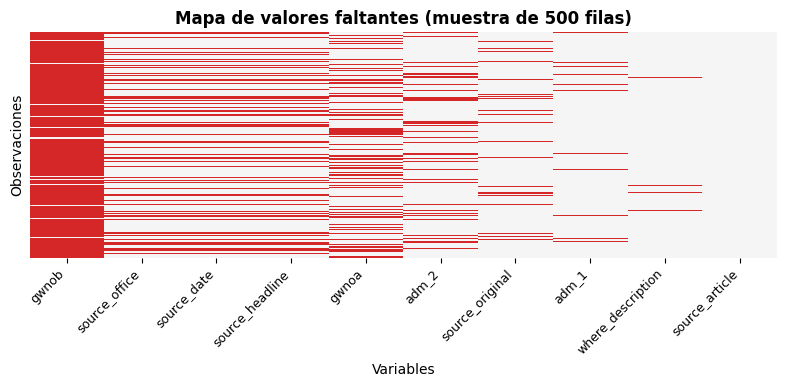

In [46]:
# ─────────────────────────────────────────────
# VISUALIZACIÓN: heatmap de faltantes
# ─────────────────────────────────────────────
if not missing_df.empty:
    cols_with_na = missing_df.index.tolist()
    # Muestra aleatoria para que el heatmap sea legible
    sample = data[cols_with_na].sample(min(500, len(data)), random_state=42)

    fig, ax = plt.subplots(figsize=(max(8, len(cols_with_na)*0.6), 4))
    sns.heatmap(
        sample.isnull(),
        cbar=False,
        yticklabels=False,
        cmap=['#f5f5f5', '#d62728'],
        ax=ax
    )
    ax.set_title("Mapa de valores faltantes (muestra de 500 filas)")
    ax.set_xlabel("Variables")
    ax.set_ylabel("Observaciones")
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()


### Clasificación del mecanismo de ausencia

| Variable | % faltante aprox. | Mecanismo | Justificación |
|---|---|---|---|
| `adm_1` / `adm_2` | Variable | **MAR** | La ausencia depende de la precisión geográfica (`where_prec`). Eventos con baja precisión (centroide de país) carecen de nivel administrativo. |
| `geom_wkt` | Alta | **MAR** | Depende del método de geocodificación; la ausencia está correlacionada con la fuente de datos. |
| `source_office` / `source_headline` | Alta | **MAR** | La disponibilidad de fuente secundaria depende del tipo de conflicto y la región (cobertura mediática). |
| `deaths_unknown` | Alta | **MNAR** | La incertidumbre sobre el número de muertes es intrínseca al evento: en conflictos muy encubiertos, las cifras desconocidas no se reportan precisamente porque son desconocidas. |
| `gwnoa` / `gwnob` | Moderada | **MAR** | Depende de si el actor es un estado reconocido por el sistema Correlates of War; actores no estatales carecen de código. |

> **Nota:** No se detectan columnas MCAR puras. La naturaleza del dataset (registro de eventos reales codificados por analistas) implica que cualquier ausencia tiene una causa relacionada con el proceso de codificación o la naturaleza del conflicto.


## Detección de outliers

Se aplica el método IQR (rango intercuartílico) sobre las variables numéricas analíticas. Dado que las distribuciones de bajas son fuertemente asimétricas (sesgadas a la derecha), se espera una proporción elevada de valores atípicos en la cola superior.

In [47]:
# ─────────────────────────────────────────────
# IQR SOBRE VARIABLES NUMÉRICAS ANALÍTICAS
# ─────────────────────────────────────────────
NUMERIC_VARS = [c for c in ['best', 'high', 'low',
                             'deaths_a', 'deaths_b',
                             'deaths_civilians', 'deaths_unknown']
                if c in data.columns]

outlier_summary = []

for col in NUMERIC_VARS:
    s = data[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lower) | (s > upper)).sum()
    pct   = n_out / len(s) * 100
    outlier_summary.append({
        'Variable'        : col,
        'Q1'              : round(q1, 2),
        'Q3'              : round(q3, 2),
        'IQR'             : round(iqr, 2),
        'Límite superior' : round(upper, 2),
        'N outliers'      : n_out,
        '% outliers'      : round(pct, 2),
        'Máximo'          : round(s.max(), 2),
    })

out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string(index=False))


        Variable  Q1  Q3  IQR  Límite superior  N outliers  % outliers  Máximo
            best 1.0 4.0  3.0              8.5       50210       13.01  121848
            high 1.0 5.0  4.0             11.0       45916       11.90  121848
             low 1.0 4.0  3.0              8.5       46614       12.08  121848
        deaths_a 0.0 0.0  0.0              0.0       94908       24.59  121848
        deaths_b 0.0 1.0  1.0              2.5       57128       14.80   19874
deaths_civilians 0.0 1.0  1.0              2.5       40484       10.49   40000
  deaths_unknown 0.0 0.0  0.0              0.0       56401       14.61   48183


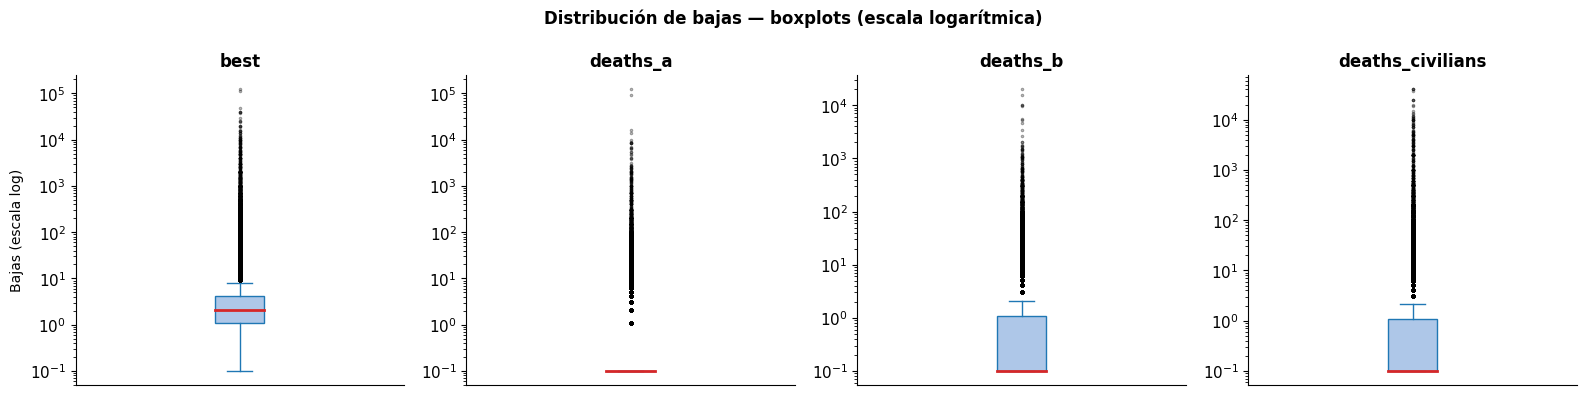

Nota: escala logarítmica aplicada para visibilidad. Los valores atípicos corresponden
a eventos masivos (guerras convencionales, masacres); son outliers estadísticos pero
son eventos reales y relevantes, por lo que NO se eliminan del análisis.


In [48]:
# ─────────────────────────────────────────────
# VISUALIZACIÓN: boxplots de bajas (escala log)
# ─────────────────────────────────────────────
death_cols = [c for c in ['best', 'deaths_a', 'deaths_b', 'deaths_civilians']
              if c in data.columns]

fig, axes = plt.subplots(1, len(death_cols), figsize=(4*len(death_cols), 4))
if len(death_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, death_cols):
    vals = data[col].dropna() + 0.1          # +0.1 para log de ceros
    ax.boxplot(vals, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
               medianprops=dict(color='#d62728', linewidth=2),
               flierprops=dict(marker='.', color='#888', markersize=3, alpha=0.4),
               whiskerprops=dict(color='#1f77b4'),
               capprops=dict(color='#1f77b4'))
    ax.set_yscale('log')
    ax.set_title(col)
    ax.set_ylabel("Bajas (escala log)" if ax is axes[0] else "")
    ax.set_xticks([])

fig.suptitle("Distribución de bajas — boxplots (escala logarítmica)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Nota: escala logarítmica aplicada para visibilidad. Los valores atípicos corresponden")
print("a eventos masivos (guerras convencionales, masacres); son outliers estadísticos pero")
print("son eventos reales y relevantes, por lo que NO se eliminan del análisis.")


## Distribuciones y patrones generales

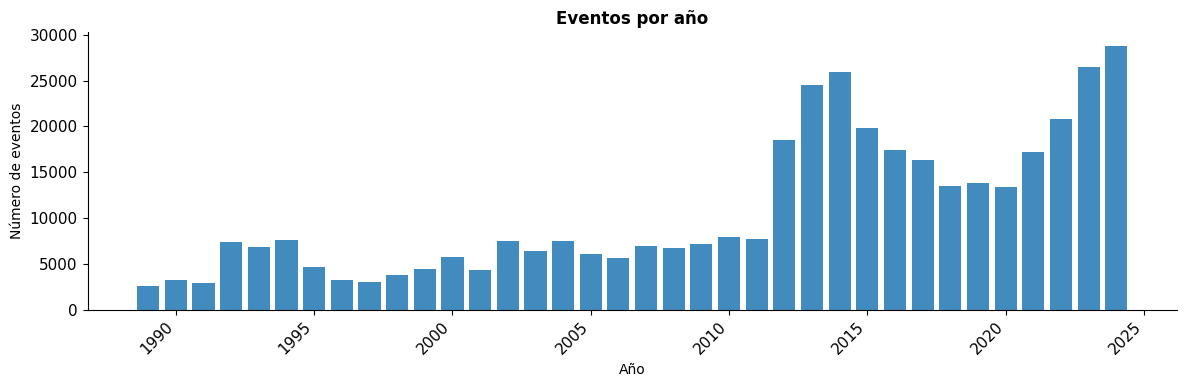

In [49]:
# ─────────────────────────────────────────────
# A. DISTRIBUCIÓN TEMPORAL — eventos por año (barras)
# ─────────────────────────────────────────────
year_col = next((c for c in data.columns if 'year' in c.lower()), None)

if year_col:
    events_per_year = data[year_col].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(events_per_year.index, events_per_year.values,
           color='#1f77b4', width=0.8, alpha=0.85)

    ax.set_title("Eventos por año")
    ax.set_xlabel("Año")
    ax.set_ylabel("Número de eventos")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


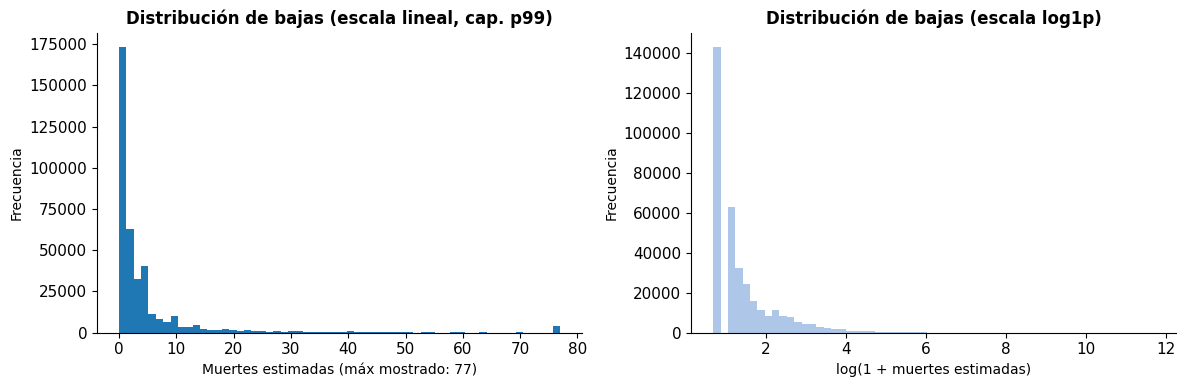

Asimetría (skewness): 232.97  → distribución fuertemente sesgada a la derecha


In [50]:
# ─────────────────────────────────────────────
# B. DISTRIBUCIÓN DE BAJAS (best) — histograma + curva KDE
# ─────────────────────────────────────────────
if 'best' in data.columns:
    vals = data['best'].dropna()
    vals_nz = vals[vals > 0]          # excluye ceros para log

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Escala lineal (censurada en percentil 99)
    cap = vals.quantile(0.99)
    axes[0].hist(vals.clip(upper=cap), bins=60, color='#1f77b4', edgecolor='none')
    axes[0].set_title("Distribución de bajas (escala lineal, cap. p99)")
    axes[0].set_xlabel(f"Muertes estimadas (máx mostrado: {cap:.0f})")
    axes[0].set_ylabel("Frecuencia")

    # Escala logarítmica
    axes[1].hist(np.log1p(vals_nz), bins=60, color='#aec7e8', edgecolor='none')
    axes[1].set_title("Distribución de bajas (escala log1p)")
    axes[1].set_xlabel("log(1 + muertes estimadas)")
    axes[1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

    skew = vals.skew()
    print(f"Asimetría (skewness): {skew:.2f}  → distribución fuertemente sesgada a la derecha")


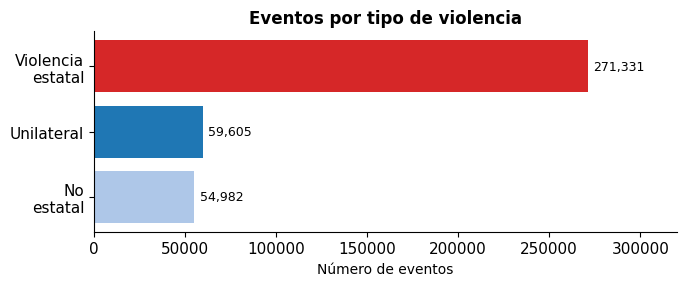

In [51]:
# ─────────────────────────────────────────────
# C. TIPO DE VIOLENCIA — gráfico de barras horizontal
# ─────────────────────────────────────────────
type_labels = {1: 'Violencia\nestatal', 2: 'No\nestatal', 3: 'Unilateral'}

if 'type_of_violence' in data.columns:
    tov = (data['type_of_violence']
           .map(type_labels)
           .value_counts()
           .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(7, 3))
    bars = ax.barh(tov.index, tov.values, color=['#aec7e8','#1f77b4','#d62728'])
    ax.bar_label(bars, labels=[f'{v:,}' for v in tov.values], padding=4, fontsize=9)
    ax.set_title("Eventos por tipo de violencia")
    ax.set_xlabel("Número de eventos")
    ax.set_xlim(0, tov.max() * 1.18)
    plt.tight_layout()
    plt.show()


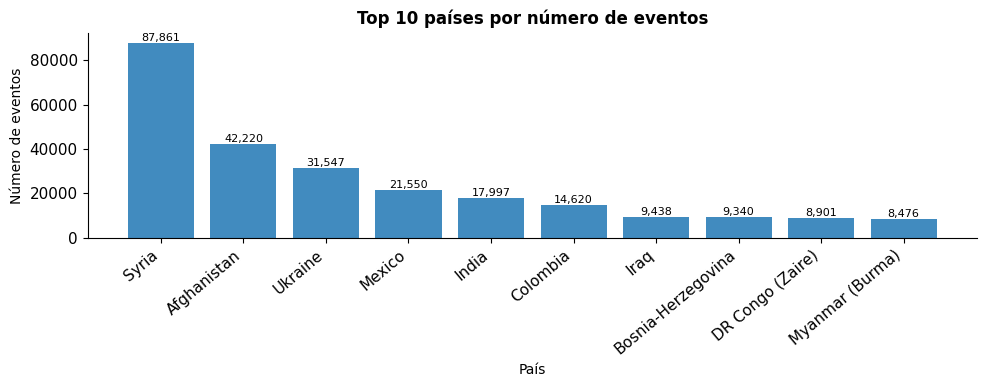

In [52]:
# ─────────────────────────────────────────────
# D. TOP 10 PAÍSES — barras verticales
# ─────────────────────────────────────────────
if 'country' in data.columns:
    top10 = data['country'].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(top10.index, top10.values, color='#1f77b4', alpha=0.85)
    ax.set_title("Top 10 países por número de eventos")
    ax.set_xlabel("País")
    ax.set_ylabel("Número de eventos")
    plt.xticks(rotation=40, ha='right')
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()


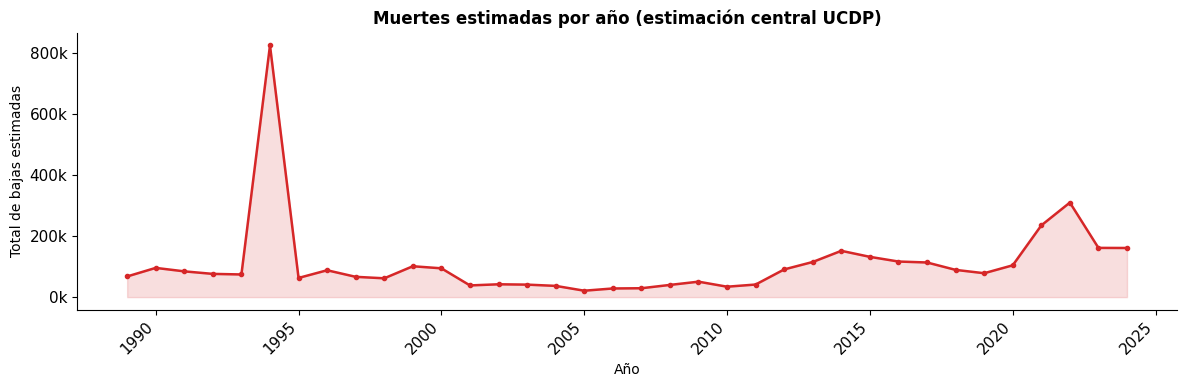

In [53]:
# ─────────────────────────────────────────────
# E. MUERTES ANUALES — línea temporal
# ─────────────────────────────────────────────
if year_col and 'best' in data.columns:
    deaths_year = data.groupby(year_col)['best'].sum()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(deaths_year.index, deaths_year.values,
            color='#d62728', linewidth=1.8, marker='o', markersize=3)
    ax.fill_between(deaths_year.index, deaths_year.values, alpha=0.15, color='#d62728')
    ax.set_title("Muertes estimadas por año (estimación central UCDP)")
    ax.set_xlabel("Año")
    ax.set_ylabel("Total de bajas estimadas")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


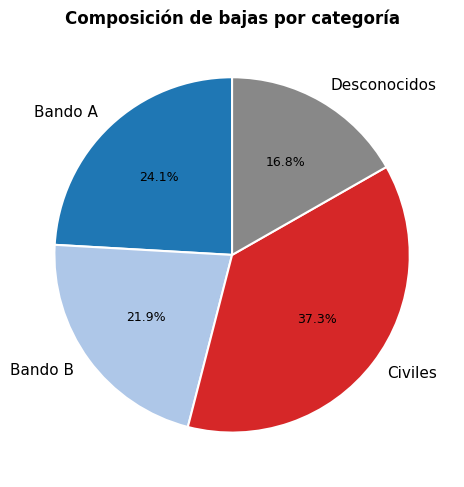

In [54]:
# ─────────────────────────────────────────────
# F. COMPOSICIÓN DE BAJAS — gráfico de torta
# ─────────────────────────────────────────────
death_map = {
    'deaths_a'        : 'Bando A',
    'deaths_b'        : 'Bando B',
    'deaths_civilians': 'Civiles',
    'deaths_unknown'  : 'Desconocidos',
}
present = {k: v for k, v in death_map.items() if k in data.columns}

if present:
    totals = {label: data[col].sum() for col, label in present.items()}
    labels = list(totals.keys())
    sizes  = list(totals.values())
    colors = ['#1f77b4','#aec7e8','#d62728','#888888']

    fig, ax = plt.subplots(figsize=(6, 5))
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5}
    )
    for t in autotexts:
        t.set_fontsize(9)
    ax.set_title("Composición de bajas por categoría")
    plt.tight_layout()
    plt.show()


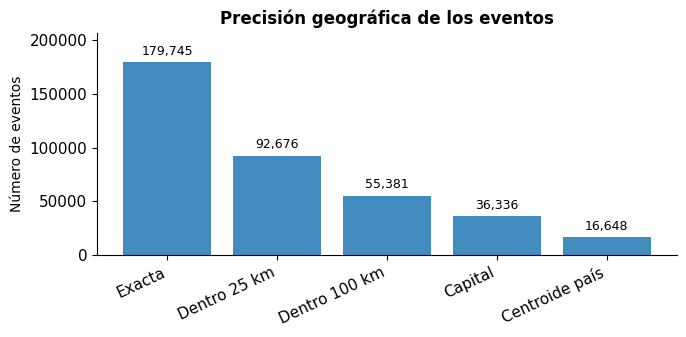

In [55]:
# ─────────────────────────────────────────────
# G. PRECISIÓN GEOGRÁFICA — barras
# ─────────────────────────────────────────────
prec_labels = {
    1: 'Exacta',
    2: 'Dentro 25 km',
    3: 'Dentro 100 km',
    4: 'Capital',
    5: 'Centroide país',
}

if 'where_prec' in data.columns:
    prec = (data['where_prec']
            .map(prec_labels)
            .value_counts()
            .reindex(prec_labels.values(), fill_value=0))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(prec.index, prec.values, color='#1f77b4', alpha=0.85)
    ax.bar_label(bars, labels=[f'{v:,}' for v in prec.values], padding=3, fontsize=9)
    ax.set_title("Precisión geográfica de los eventos")
    ax.set_ylabel("Número de eventos")
    ax.set_ylim(0, prec.max() * 1.15)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()


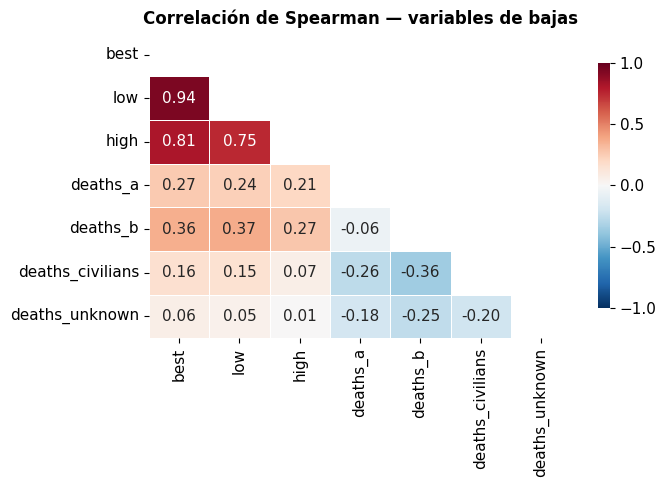

Interpretación: correlación alta entre best/low/high es esperada (son
estimaciones del mismo evento). La correlación con deaths_civilians indica
si los conflictos más letales afectan proporcionalmente más a la población civil.


In [56]:
# ─────────────────────────────────────────────
# H. MATRIZ DE CORRELACIÓN — variables de bajas
# ─────────────────────────────────────────────
corr_cols = [c for c in ['best', 'low', 'high',
                          'deaths_a', 'deaths_b',
                          'deaths_civilians', 'deaths_unknown']
             if c in data.columns]

if len(corr_cols) > 1:
    corr_matrix = data[corr_cols].corr(method='spearman')

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'shrink': 0.8}
    )
    ax.set_title("Correlación de Spearman — variables de bajas")
    plt.tight_layout()
    plt.show()
    print("Interpretación: correlación alta entre best/low/high es esperada (son")
    print("estimaciones del mismo evento). La correlación con deaths_civilians indica")
    print("si los conflictos más letales afectan proporcionalmente más a la población civil.")


## Interpretación general

A partir del análisis exploratorio se pueden extraer las siguientes conclusiones:

1. **Tendencia temporal**: el número de eventos registrados muestra una tendencia creciente a partir de la segunda mitad del siglo XX, con picos coincidentes con conflictos regionales conocidos. Esto puede deberse tanto a un incremento real de los conflictos como a una mejora en la cobertura mediática y los sistemas de recolección de datos.

2. **Distribución asimétrica de bajas**: la variable `best` presenta una asimetría positiva marcada (skewness elevado). La mayoría de los eventos tienen pocas bajas, pero la cola derecha contiene eventos extremos que concentran una fracción significativa del total de muertes. Esto justifica el uso de escala logarítmica y métricas robustas (mediana, IQR) en lugar de la media.

3. **Dominio del conflicto estatal**: el tipo de violencia más frecuente es el conflicto entre estados o entre gobiernos y grupos armados (`type_of_violence = 1`), aunque la violencia unilateral (masacres, ataques a civiles) aporta una proporción significativa de bajas civiles.

4. **Concentración geográfica**: un número reducido de países concentra la mayoría de los eventos, lo que sugiere que factores estructurales (fragilidad estatal, recursos naturales, historia colonial) son determinantes en la persistencia de los conflictos.

5. **Calidad de los datos**: la mayoría de los eventos tienen localización exacta (`where_prec = 1`), lo que indica alta calidad geoespacial del dataset. Los valores faltantes se concentran en columnas auxiliares (texto libre, códigos de actor no estatal) y responden a mecanismos MAR o MNAR, no a pérdida aleatoria.

6. **Outliers preservados**: los valores atípicos en las variables de bajas corresponden a eventos históricos documentados (guerras convencionales, genocidios). No se eliminan porque son eventos reales con alta relevancia analítica; deben tratarse con transformaciones (log) en modelos predictivos.
